### EMPIRICAL VALIDATION

In [12]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# LOAD & CONSOLIDATE 12 MONTHS CSVs
OUTPUT_DIR = Path('OUTPUT')
csv_files = sorted(OUTPUT_DIR.glob('od_*.csv'))
print("Found files:", [f.name for f in csv_files])

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    dfs.append(df)

od = pd.concat(dfs, ignore_index=True)
print(f'COMBINED SHAPE: {od.shape}')
print(f'EXPECTED TOTAL ROWS: {365*20*169 + 2*169}')  # 365 days standard + 2 extra NYE hours
od.head()

Found files: ['od_202506.csv', 'od_202507.csv', 'od_202508.csv', 'od_202509.csv', 'od_202510.csv', 'od_202511.csv', 'od_202512.csv', 'od_202601.csv', 'od_202602.csv', 'od_202603.csv', 'od_202604.csv', 'od_202605.csv']
COMBINED SHAPE: (1234038, 6)
EXPECTED TOTAL ROWS: 1234038


,hour_start,hour_end,origin,destination,count,service_date_ce
0,5,6,TLC,TLC,0.0,2025-06-01
1,5,6,TLC,BMR,0.0,2025-06-01
2,5,6,TLC,BSN,0.0,2025-06-01
3,5,6,TLC,KTW,0.0,2025-06-01
4,5,6,TLC,CTK,0.0,2025-06-01


In [6]:
# DATE PARSING & DAY-OF-WEEK FLAGS
od['service_date_ce'] = pd.to_datetime(od['service_date_ce'])
od['day_of_week'] = od['service_date_ce'].dt.day_name()
od['is_weekend'] = od['service_date_ce'].dt.dayofweek >= 5  # Sat=5, Sun=6
od['month'] = od['service_date_ce'].dt.to_period('M')

print(od[['service_date_ce','day_of_week','is_weekend','month']].head())
print()
print(od['day_of_week'].value_counts())
print()
print(od['is_weekend'].value_counts())

  service_date_ce day_of_week  is_weekend    month
0      2025-06-01      Sunday        True  2025-06
1      2025-06-01      Sunday        True  2025-06
2      2025-06-01      Sunday        True  2025-06
3      2025-06-01      Sunday        True  2025-06
4      2025-06-01      Sunday        True  2025-06

day_of_week
Sunday       179140
Wednesday    176098
Monday       175760
Tuesday      175760
Thursday     175760
Friday       175760
Saturday     175760
Name: count, dtype: int64

is_weekend
False    879138
True     354900
Name: count, dtype: int64


In [7]:
# RANGSIT HOURLY DEMAND PROFILE: ENTRIES (TAP-IN) AND EXITS (TAP-OUT)
rst_entries = od[od['origin'] == 'RST'].groupby(['is_weekend','hour_start'])['count'].sum().reset_index()
rst_entries['type'] = 'entry'

rst_exits = od[od['destination'] == 'RST'].groupby(['is_weekend','hour_start'])['count'].sum().reset_index()
rst_exits['type'] = 'exit'

rst_profile = pd.concat([rst_entries, rst_exits], ignore_index=True)
print(rst_profile.head(10))
print()
print(f"Total RST entries (year): {rst_entries['count'].sum():,.0f}")
print(f"Total RST exits (year): {rst_exits['count'].sum():,.0f}")

   is_weekend  hour_start     count   type
0       False           0    1291.0  entry
1       False           1      73.0  entry
2       False           2      65.0  entry
3       False           5   15706.0  entry
4       False           6   73227.0  entry
5       False           7  204956.0  entry
6       False           8  165819.0  entry
7       False           9   68761.0  entry
8       False          10   45390.0  entry
9       False          11   40197.0  entry

Total RST entries (year): 1,377,924
Total RST exits (year): 1,470,615


In [8]:
# NORMALIZE TO AVERAGE PER-DAY PROFILE (weekday vs weekend day counts differ)
n_weekday_days = od[od['is_weekend']==False]['service_date_ce'].nunique()
n_weekend_days = od[od['is_weekend']==True]['service_date_ce'].nunique()
print(f"Weekday days: {n_weekday_days}, Weekend days: {n_weekend_days}")

rst_profile['n_days'] = rst_profile['is_weekend'].map({False: n_weekday_days, True: n_weekend_days})
rst_profile['avg_per_day'] = rst_profile['count'] / rst_profile['n_days']

# PIVOT FOR PLOTTING
pivot = rst_profile.pivot_table(index='hour_start', columns=['type','is_weekend'], values='avg_per_day')
print(pivot)

Weekday days: 260, Weekend days: 105
type             entry                    exit            
is_weekend       False       True        False       True 
hour_start                                                
0             4.965385    7.447619   17.353846   24.333333
1             0.280769         NaN    0.492308         NaN
2             0.250000         NaN    0.446154         NaN
5            60.407692   35.800000   16.042308   15.790476
6           281.642308  113.609524   63.484615   58.780952
7           788.292308  197.238095  150.311538  136.466667
8           637.765385  224.342857  162.734615  150.961905
9           264.465385  219.247619  121.573077  157.761905
10          174.576923  224.123810  130.384615  180.809524
11          154.603846  233.371429  153.342308  203.123810
12          156.196154  239.723810  151.696154  196.457143
13          145.819231  254.095238  155.538462  204.152381
14          135.638462  230.942857  166.884615  218.609524
15          140.546

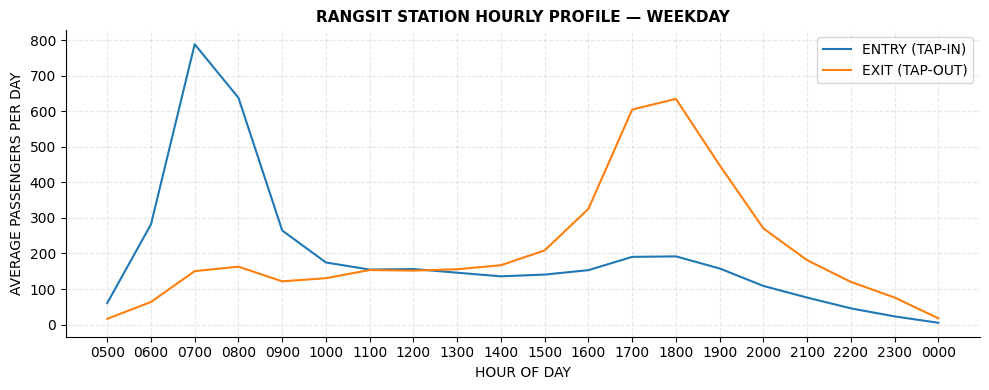

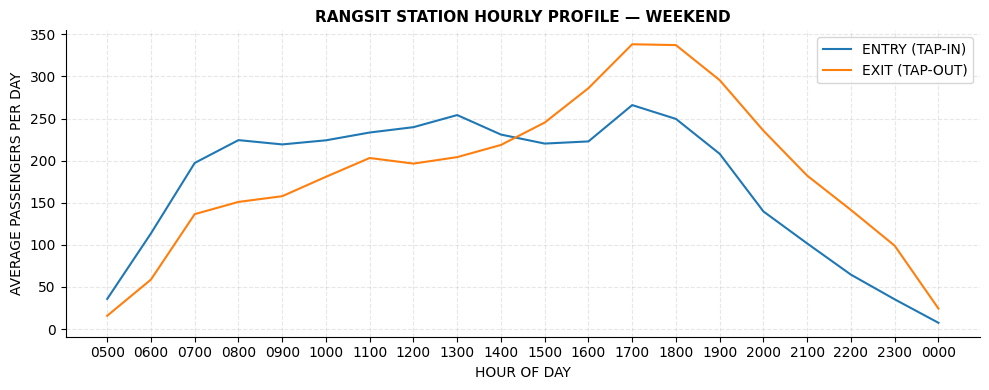

In [18]:
# RANGSIT STATION HOURLY PROFILE
# HOURS TO OPERATIONAL DAY: 05:00 -> 23:00 -> 00:00(-01:00)
hour_order = list(range(5,24)) + [0]

for wknd, label in [(False, 'WEEKDAY'), (True, 'WEEKEND')]:
    sub = pivot.xs(wknd, axis=1, level='is_weekend').reindex(hour_order)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(len(sub)), sub['entry'], label='ENTRY (TAP-IN)')
    ax.plot(range(len(sub)), sub['exit'], label='EXIT (TAP-OUT)')

    ax.set_title(f'RANGSIT STATION HOURLY PROFILE — {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('HOUR OF DAY')
    ax.set_ylabel('AVERAGE PASSENGERS PER DAY')
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels([f'{h:02d}00' for h in hour_order])
    ax.legend()
    ax.grid(True, linestyle='--',alpha=0.3)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'OUTPUT/rangsit_hourly_profile_{label.lower()}.png', dpi=300)
    plt.show()

In [19]:
# PEAK-HOUR METRICS FOR COMPARISON WITH SIMULATION ASSUMPTIONS
for wknd, label in [(False, 'WEEKDAY'), (True, 'WEEKEND')]:
    sub = pivot.xs(wknd, axis=1, level='is_weekend').reindex(hour_order)
    daily_entry_total = sub['entry'].sum()
    daily_exit_total = sub['exit'].sum()

    am_peak_hr = sub['entry'].idxmax()
    pm_peak_hr = sub['exit'].idxmax()

    am_peak_share = sub['entry'].max() / daily_entry_total
    pm_peak_share = sub['exit'].max() / daily_exit_total

    print(f"--- {label} ---")
    print(f"AM entry peak: hour {am_peak_hr}, {sub['entry'].max():.0f}/day, "
          f"{am_peak_share:.1%} of daily entries")
    print(f"PM exit peak: hour {pm_peak_hr}, {sub['exit'].max():.0f}/day, "
          f"{pm_peak_share:.1%} of daily exits")
    print(f"Peak-to-mean ratio (entry): {sub['entry'].max()/sub['entry'].mean():.2f}x")
    print(f"Peak-to-mean ratio (exit): {sub['exit'].max()/sub['exit'].mean():.2f}x")
    print()

--- WEEKDAY ---
AM entry peak: hour 7, 788/day, 20.3% of daily entries
PM exit peak: hour 18, 635/day, 15.3% of daily exits
Peak-to-mean ratio (entry): 4.05x
Peak-to-mean ratio (exit): 3.05x

--- WEEKEND ---
AM entry peak: hour 17, 266/day, 7.6% of daily entries
PM exit peak: hour 17, 338/day, 9.1% of daily exits
Peak-to-mean ratio (entry): 1.52x
Peak-to-mean ratio (exit): 1.82x



In [21]:
# COMPUTE PEAKING FACTORS FOR ALL STATIONS (WEEKDAY)
STATIONS = ['TLC','BMR','BSN','KTW','CTK','WSN','BKH','TSH','LAK','KHA','DMG','LHK','RST']
hour_order = list(range(5,24)) + [0,1,2]
station_metrics = []

for station in STATIONS:
    entries = od[(od['origin']==station) & (od['is_weekend']==False)].groupby('hour_start')['count'].sum()
    exits = od[(od['destination']==station) & (od['is_weekend']==False)].groupby('hour_start')['count'].sum()

    entries_avg = entries / n_weekday_days
    exits_avg = exits / n_weekday_days

    daily_entry_total = entries_avg.sum()
    daily_exit_total = exits_avg.sum()

    am_peak_hr = entries_avg.idxmax()
    pm_peak_hr = exits_avg.idxmax()

    am_peak_share = entries_avg.max() / daily_entry_total
    pm_peak_share = exits_avg.max() / daily_exit_total

    station_metrics.append({
        'station': station,
        'daily_entry_total': daily_entry_total,
        'daily_exit_total': daily_exit_total,
        'am_peak_hr': am_peak_hr,
        'am_peak_share': am_peak_share,
        'pm_peak_hr': pm_peak_hr,
        'pm_peak_share': pm_peak_share,
        'entry_peak_to_mean': entries_avg.max()/entries_avg.mean(),
        'exit_peak_to_mean': exits_avg.max()/exits_avg.mean(),
    })

metrics_df = pd.DataFrame(station_metrics)
metrics_df = metrics_df.sort_values('daily_entry_total', ascending=False)
print(metrics_df.to_string(index=False))

station  daily_entry_total  daily_exit_total  am_peak_hr  am_peak_share  pm_peak_hr  pm_peak_share  entry_peak_to_mean  exit_peak_to_mean
    KTW        8321.157692       8902.896154          18       0.131719           7       0.138489            2.897826           3.046750
    DMG        6038.134615       5110.350000           7       0.089204          17       0.114781            1.962478           2.525191
    RST        3891.203846       4158.957692           7       0.202583          18       0.152577            4.456829           3.356695
    LAK        3766.557692       3866.000000          17       0.130999           7       0.115524            2.881979           2.541526
    BKH        1877.719231       1824.203846          17       0.199448           8       0.216758            4.387860           4.768685
    LHK        1789.276923       1659.761538           7       0.151037          18       0.125442            3.322803           2.759725
    WSN        1019.180769       1

___
**END**